In [3]:
import subprocess, sys
for pkg in ['pandas', 'numpy','matplotlib','seaborn','plotly','openpyxl']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All libraries are installed')

All libraries are installed


In [4]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('libraries imported successfully!')

libraries imported successfully!


In [6]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('sales_records_dataset.xlsx')
print(f'Dataset loaded! Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded! Shape: 1000 rows x 14 columns


In [7]:
df.head(5)

,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [8]:
df.shape

(1000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          955 non-null    object 
 1   Customer_Name     956 non-null    object 
 2   Gender            949 non-null    object 
 3   Region            941 non-null    object 
 4   Product_Category  944 non-null    object 
 5   Product_Name      961 non-null    object 
 6   Quantity          955 non-null    float64
 7   Unit_Price        949 non-null    float64
 8   Total_Sales       942 non-null    float64
 9   Discount          950 non-null    float64
 10  Profit            947 non-null    float64
 11  Order_Date        945 non-null    object 
 12  Payment_Method    944 non-null    object 
 13  Sales_Rep         955 non-null    object 
dtypes: float64(5), object(9)
memory usage: 109.5+ KB


In [10]:
df.describe().round(2)

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


In [3]:
import pandas as pd
df = pd.read_excel('sales_records_dataset.xlsx')
df.isnull().sum()

Order_ID            45
Customer_Name       44
Gender              51
Region              59
Product_Category    56
Product_Name        39
Quantity            45
Unit_Price          51
Total_Sales         58
Discount            50
Profit              53
Order_Date          55
Payment_Method      56
Sales_Rep           45
dtype: int64

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('columns with missing values:')

columns with missing values:


In [9]:
missing_df

,Missing Count,Missing %
Region,59,5.9
Total_Sales,58,5.8
Product_Category,56,5.6
Payment_Method,56,5.6
Order_Date,55,5.5
Profit,53,5.3
Gender,51,5.1
Unit_Price,51,5.1
Discount,50,5.0
Order_ID,45,4.5


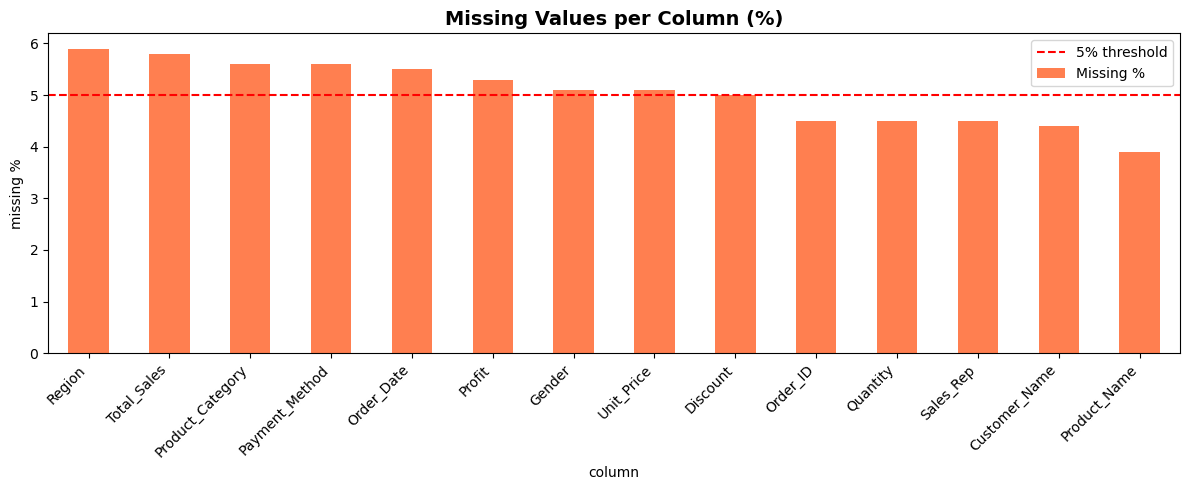

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
missing_df['Missing %'].plot(kind='bar', color='coral', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('column')
ax.set_ylabel('missing %')                       
ax.axhline(5, color='red', linestyle='--', label='5% threshold')                       
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()                       

In [15]:
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep']
for col in cat_cols:
    print(f'\n {col}:')
    print(df[col].value_counts(dropna=False).to_string())


 Gender:
Gender
Female    491
Male      458
NaN        51

 Region:
Region
South    258
East     239
West     232
North    212
NaN       59

 Product_Category:
Product_Category
Furniture      208
Electronics    204
Food           202
Clothing       184
Books          146
NaN             56

 Payment_Method:
Payment_Method
POS         253
Transfer    235
Online      234
Cash        222
NaN          56

 Sales_Rep:
Sales_Rep
Rep_D    251
Rep_A    249
Rep_C    230
Rep_B    225
NaN       45
